/var/folders/m2/kj3jnz6d03z1s37zqkzg8xbm0000gn/T/ipykernel_81826/3595420359.py:80: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  zillow_filtered['change'] = (zillow_filtered.iloc[:, -1] - zillow_filtered.iloc[:, 1]) / zillow_filtered.iloc[:, 1] * 100


Original housing price data statistics:
Housing price change - Min: -16.346, Max: 76.692

Winsorized housing price data statistics:
Housing price change - Min: 1.698, Max: 29.711

Observations winsorized:
Housing price change: 298 out of 2966 (10.0%)


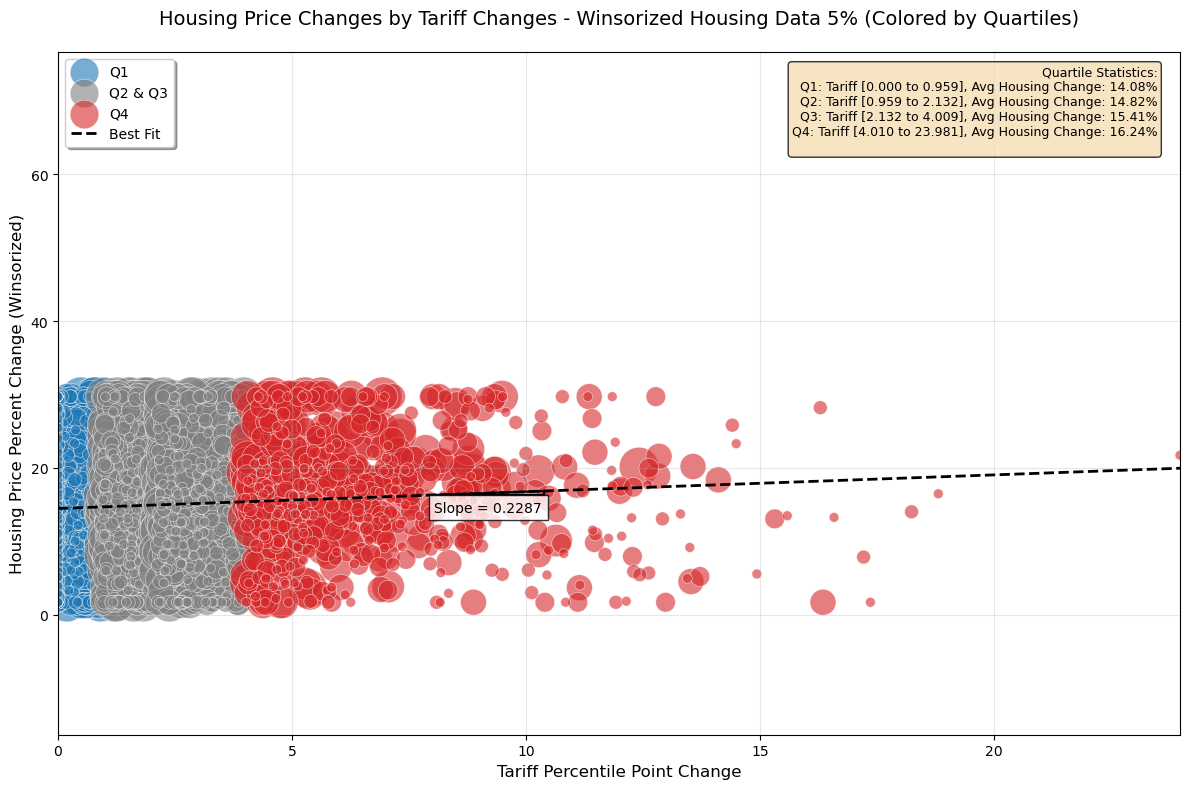


Housing-winsorized quartile-colored scatterplot saved to Images/Quartile_Scatterplot_Housing_Winsorized_5pct.png

Quartile distribution:
Q1    742
Q2    741
Q3    741
Q4    742
Name: quartile, dtype: int64


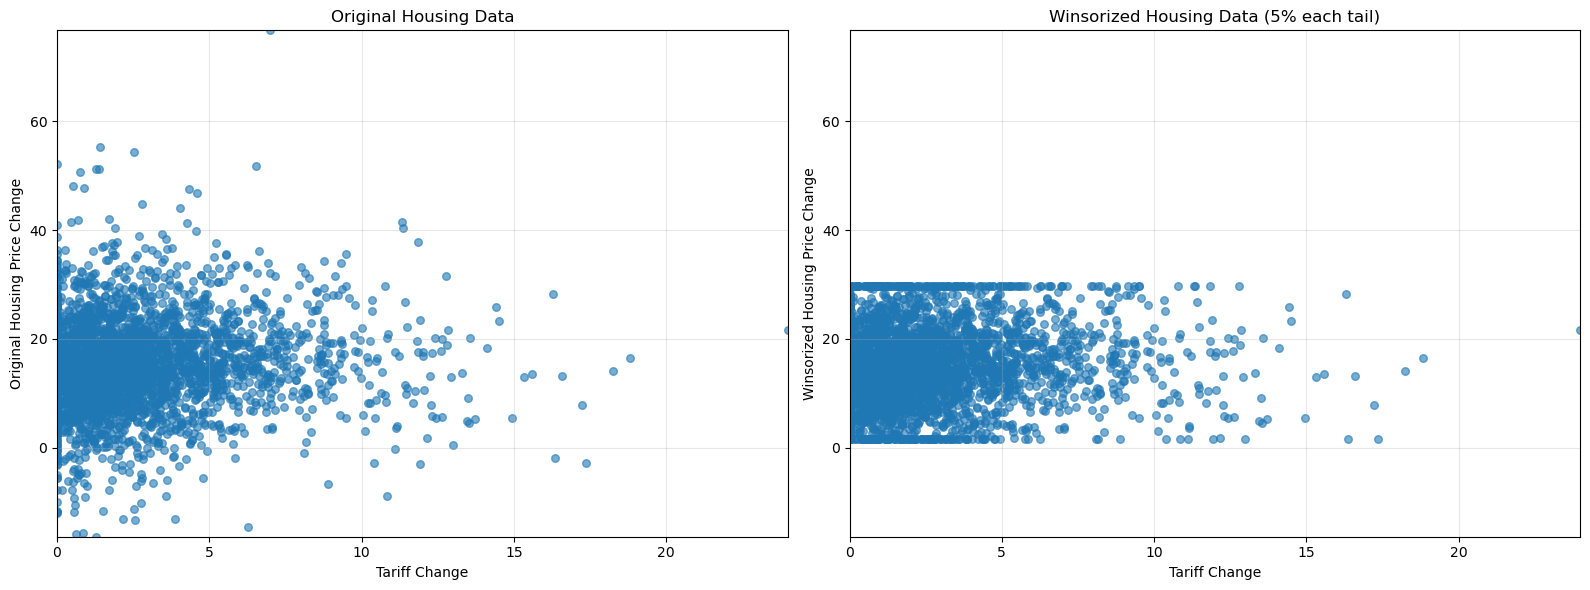

Housing comparison plot saved to Images/Original_vs_Winsorized_Housing_Comparison_5pct.png


In [17]:
#!/usr/bin/env python
# coding: utf-8

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import os
from datetime import datetime, timedelta

# Load the data
tariff = pd.read_csv('Data/ustariffs-by-county.csv')
zillow = pd.read_csv('Data/zillow county.csv')

# Clean tariff data
tariff_columns_drop = ['Unnamed: 0','total_imp_pc','china_imp_pc','emplvl_2017','total_employment','int_area_fips','2017_income','area_fips']
tariff = tariff.drop(columns=tariff_columns_drop)

# Convert time column and filter date range
tariff['time'] = pd.to_datetime(tariff['time'])
tariff = tariff[(tariff['time'] >= '2017-01-01') & (tariff['time'] <= '2019-12-31')]

# Create pivoted tariff DataFrame
pivoted_tariff = tariff.pivot(index='fips', columns='time', values='tariff')

# Add population data
population_data = tariff.dropna(subset=['2017_population']).drop_duplicates(subset=['fips'], keep='first')[['fips', '2017_population']]
population_data = population_data.set_index('fips')
pivoted_tariff = pivoted_tariff.join(population_data)

# Rename columns to shift dates back by one day (to match original logic)
current_columns = pivoted_tariff.columns.tolist()
column_mapping = {}

for col in current_columns:
    if isinstance(col, str) and '-' in col:  # Check if it's a date string
        try:
            current_date = pd.to_datetime(col)
            new_date = current_date - timedelta(days=1)
            new_date_str = new_date.strftime('%Y-%m-%d')
            column_mapping[col] = new_date_str
        except:
            column_mapping[col] = col
    else:
        column_mapping[col] = col

pivoted_tariff = pivoted_tariff.rename(columns=column_mapping).reset_index()

# Calculate tariff change
first_date = pivoted_tariff.columns[1]  
last_date = pivoted_tariff.columns[-2]  
pivoted_tariff['tariff_change'] = pivoted_tariff[last_date] - pivoted_tariff[first_date]

# Process Zillow data
# Create FIPS code
zillow['StateCodeFIPS'] = zillow['StateCodeFIPS'].astype(str).str.zfill(2)
zillow['MunicipalCodeFIPS'] = zillow['MunicipalCodeFIPS'].astype(str).str.zfill(3)
zillow['fips'] = zillow['StateCodeFIPS'] + zillow['MunicipalCodeFIPS']
zillow['fips'] = zillow['fips'].astype(int)

# Drop unnecessary columns
zillow_drop_columns = ['RegionID','SizeRank','RegionName','RegionType','StateName','State','Metro','StateCodeFIPS','MunicipalCodeFIPS']
zillow = zillow.drop(columns=zillow_drop_columns)

# Keep only fips and date columns between 2017 and 2019
all_columns = zillow.columns.tolist()
columns_to_keep = ['fips']

for column in all_columns:
    if isinstance(column, str) and len(column) == 10 and column[4] == '-' and column[7] == '-':
        try:
            year = int(column.split('-')[0])
            if 2017 <= year <= 2019:
                columns_to_keep.append(column)
        except:
            pass

zillow_filtered = zillow[columns_to_keep]

# Calculate housing price percentage change
zillow_filtered['change'] = (zillow_filtered.iloc[:, -1] - zillow_filtered.iloc[:, 1]) / zillow_filtered.iloc[:, 1] * 100

# Prepare final datasets
zillow_filtered = zillow_filtered[['fips','change']].dropna()
tariff_filtered = pivoted_tariff[['fips','tariff_change','2017_population']]

# Merge the datasets
scatter_data = zillow_filtered.merge(tariff_filtered, how='inner', left_on='fips', right_on='fips')
scatter_data = scatter_data.dropna()

# WINSORIZATION FUNCTION
def winsorize(data, limits=(0.05, 0.05)):
    """
    Winsorize data by replacing extreme values with percentile values.
    
    Parameters:
    data: pandas Series or numpy array
    limits: tuple of (lower_limit, upper_limit) as proportions (e.g., 0.05 = 5%)
    
    Returns:
    winsorized data
    """
    lower_limit, upper_limit = limits
    lower_percentile = lower_limit * 100
    upper_percentile = (1 - upper_limit) * 100
    
    lower_bound = np.percentile(data, lower_percentile)
    upper_bound = np.percentile(data, upper_percentile)
    
    # Create a copy to avoid modifying original data
    winsorized_data = data.copy()
    winsorized_data = np.where(winsorized_data < lower_bound, lower_bound, winsorized_data)
    winsorized_data = np.where(winsorized_data > upper_bound, upper_bound, winsorized_data)
    
    return winsorized_data

# Apply winsorization to housing price changes only (5% on each tail)
print("Original housing price data statistics:")
print(f"Housing price change - Min: {scatter_data['change'].min():.3f}, Max: {scatter_data['change'].max():.3f}")

# Winsorize only the housing price change data
scatter_data['change_winsorized'] = winsorize(scatter_data['change'], limits=(0.05, 0.05))

print("\nWinsorized housing price data statistics:")
print(f"Housing price change - Min: {scatter_data['change_winsorized'].min():.3f}, Max: {scatter_data['change_winsorized'].max():.3f}")

# Show how many observations were winsorized
housing_winsorized_count = np.sum((scatter_data['change'] != scatter_data['change_winsorized']))

print(f"\nObservations winsorized:")
print(f"Housing price change: {housing_winsorized_count} out of {len(scatter_data)} ({housing_winsorized_count/len(scatter_data)*100:.1f}%)")

# CREATE QUARTILES USING ORIGINAL TARIFF DATA
scatter_data['quartile'] = pd.qcut(scatter_data['tariff_change'], q=4, labels=['Q1', 'Q2', 'Q3', 'Q4'])

# Define colors for each quartile
quartile_colors = {
    'Q1': '#1f77b4',    # Blue for Q1 (highest tariff changes)
    'Q2': '#808080',    # Gray for Q2 and Q3 (middle quartiles)
    'Q3': '#808080',    # Gray for Q2 and Q3 (middle quartiles)  
    'Q4': '#d62728'     # Red for Q4 (lowest tariff changes)
}

# Map colors to each data point
colors = scatter_data['quartile'].map(quartile_colors)

# Prepare data for plotting (winsorized housing, original tariff)
y = scatter_data['change_winsorized']
x = scatter_data['tariff_change']
populations = scatter_data['2017_population']

# Create 6 distinct size categories using population percentiles
population_bins = np.percentile(populations, [0, 16.6, 33.3, 50, 66.6, 83.3, 100])
size_values = [50, 100, 200, 350, 550, 800]

# Assign each data point to a size category
sizes = np.zeros_like(populations, dtype=float)
for i in range(len(population_bins)-1):
    mask = (populations >= population_bins[i]) & (populations <= population_bins[i+1])
    sizes[mask] = size_values[i]

# Create the scatter plot with quartile colors
fig, ax = plt.subplots(figsize=(12, 8))

# Plot each quartile separately for better legend control
legend_labels_added = set()
for quartile in ['Q1', 'Q2', 'Q3', 'Q4']:
    mask = scatter_data['quartile'] == quartile
    
    if quartile in ['Q2', 'Q3']:
        # Combine Q2 and Q3 in legend
        if 'Q2 & Q3' not in legend_labels_added:
            label = 'Q2 & Q3'
            legend_labels_added.add('Q2 & Q3')
        else:
            label = None
    else:
        label = f'{quartile}'
    
    ax.scatter(x[mask], y[mask], s=sizes[mask], 
               c=quartile_colors[quartile], alpha=0.6, 
               label=label, edgecolors='white', linewidth=0.5)

# Calculate and add the line of best fit (using winsorized data)
slope, intercept = np.polyfit(x, y, 1)
x_line = np.array([min(x), max(x)])
y_line = slope * x_line + intercept

# Plot the best fit line as dotted
ax.plot(x_line, y_line, color='black', linestyle='--', linewidth=2, 
         label='Best Fit')

# Create a slope marker
x_marker = x_line[0] + (x_line[1] - x_line[0]) / 3
y_marker = slope * x_marker + intercept

# Draw the slope triangle
dx = (max(x) - min(x)) * 0.1
dy = dx * slope

ax.plot([x_marker, x_marker + dx], [y_marker, y_marker], 'k-', linewidth=1.5)
ax.plot([x_marker + dx, x_marker + dx], [y_marker, y_marker + dy], 'k-', linewidth=1.5)
ax.plot([x_marker, x_marker + dx], [y_marker, y_marker + dy], 'k-', linewidth=1.5)

# Add slope text
ax.text(x_marker + dx/2, y_marker + dy/2 - 2, f'Slope = {slope:.4f}', 
         ha='center', va='center', bbox=dict(facecolor='white', alpha=0.8, edgecolor='black'))

# Set axis limits to match original data scale
original_y_min = scatter_data['change'].min()
original_y_max = scatter_data['change'].max()
original_x_min = scatter_data['tariff_change'].min()
original_x_max = scatter_data['tariff_change'].max()

ax.set_xlim(original_x_min, original_x_max)
ax.set_ylim(original_y_min, original_y_max)

# Customize the plot
ax.set_xlabel('Tariff Percentile Point Change', fontsize=12)
ax.set_ylabel('Housing Price Percent Change (Winsorized)', fontsize=12)
ax.set_title('Housing Price Changes by Tariff Changes - Winsorized Housing Data 5% (Colored by Quartiles)', fontsize=14, pad=20)
ax.grid(True, alpha=0.3)

# Add legend
ax.legend(loc='upper left', frameon=True, fancybox=True, shadow=True)

# Add quartile statistics as text box (winsorized housing, original tariff)
quartile_stats = scatter_data.groupby('quartile').agg({
    'tariff_change': ['min', 'max', 'mean'],
    'change_winsorized': 'mean'
}).round(3)

stats_text = "Quartile Statistics:\n"
for q in ['Q1', 'Q2', 'Q3', 'Q4']:
    tariff_range = f"{quartile_stats.loc[q, ('tariff_change', 'min')]:.3f} to {quartile_stats.loc[q, ('tariff_change', 'max')]:.3f}"
    housing_mean = quartile_stats.loc[q, ('change_winsorized', 'mean')]
    stats_text += f"{q}: Tariff [{tariff_range}], Avg Housing Change: {housing_mean:.2f}%\n"

ax.text(0.98, 0.98, stats_text, transform=ax.transAxes, fontsize=9,
        verticalalignment='top', horizontalalignment='right', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))

plt.tight_layout()

# Save the plot
os.makedirs('Images', exist_ok=True)
output_path = os.path.join('Images', 'Quartile_Scatterplot_Housing_Winsorized_5pct.png')
plt.savefig(output_path, dpi=300, bbox_inches='tight', pad_inches=0.1)
plt.show()

print(f"\nHousing-winsorized quartile-colored scatterplot saved to {output_path}")
print(f"\nQuartile distribution:")
print(scatter_data['quartile'].value_counts().sort_index())

# Optional: Create comparison plot showing original vs winsorized housing data
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Get the same scale for both plots
y_min = scatter_data['change'].min()
y_max = scatter_data['change'].max()
x_min = scatter_data['tariff_change'].min()
x_max = scatter_data['tariff_change'].max()

# Original data
ax1.scatter(scatter_data['tariff_change'], scatter_data['change'], alpha=0.6, s=30)
ax1.set_xlabel('Tariff Change')
ax1.set_ylabel('Original Housing Price Change')
ax1.set_title('Original Housing Data')
ax1.set_xlim(x_min, x_max)
ax1.set_ylim(y_min, y_max)
ax1.grid(True, alpha=0.3)

# Winsorized housing data
ax2.scatter(scatter_data['tariff_change'], scatter_data['change_winsorized'], alpha=0.6, s=30)
ax2.set_xlabel('Tariff Change')
ax2.set_ylabel('Winsorized Housing Price Change')
ax2.set_title('Winsorized Housing Data (5% each tail)')
ax2.set_xlim(x_min, x_max)
ax2.set_ylim(y_min, y_max)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
comparison_path = os.path.join('Images', 'Original_vs_Winsorized_Housing_Comparison_5pct.png')
plt.savefig(comparison_path, dpi=300, bbox_inches='tight')
plt.show()

print(f"Housing comparison plot saved to {comparison_path}")

/var/folders/m2/kj3jnz6d03z1s37zqkzg8xbm0000gn/T/ipykernel_81826/2400787131.py:80: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  zillow_filtered['change'] = (zillow_filtered.iloc[:, -1] - zillow_filtered.iloc[:, 1]) / zillow_filtered.iloc[:, 1] * 100


Original housing price data statistics:
Housing price change - Min: -16.346, Max: 76.692

Winsorized housing price data statistics:
Housing price change - Min: -6.213, Max: 37.640

Observations winsorized:
Housing price change: 60 out of 2966 (2.0%)


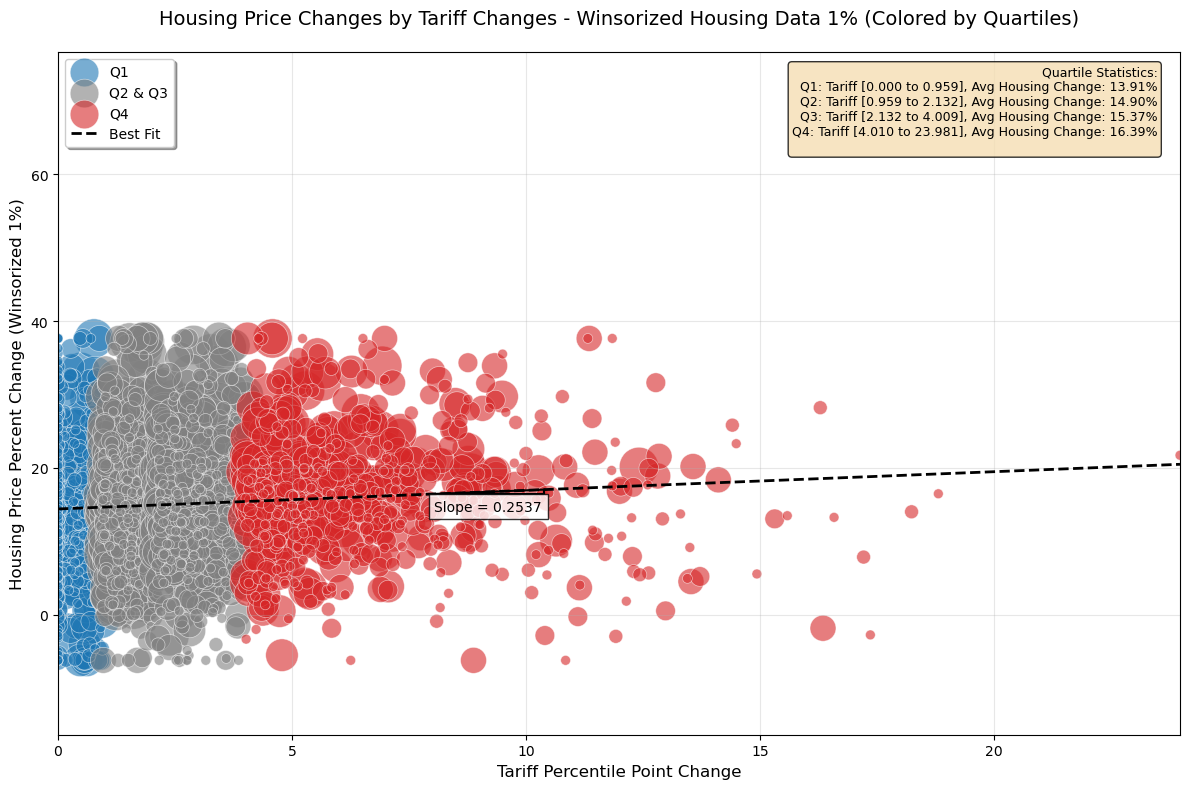


Housing-winsorized (1%) quartile-colored scatterplot saved to Images/Quartile_Scatterplot_Housing_Winsorized_1pct.png

Quartile distribution:
Q1    742
Q2    741
Q3    741
Q4    742
Name: quartile, dtype: int64


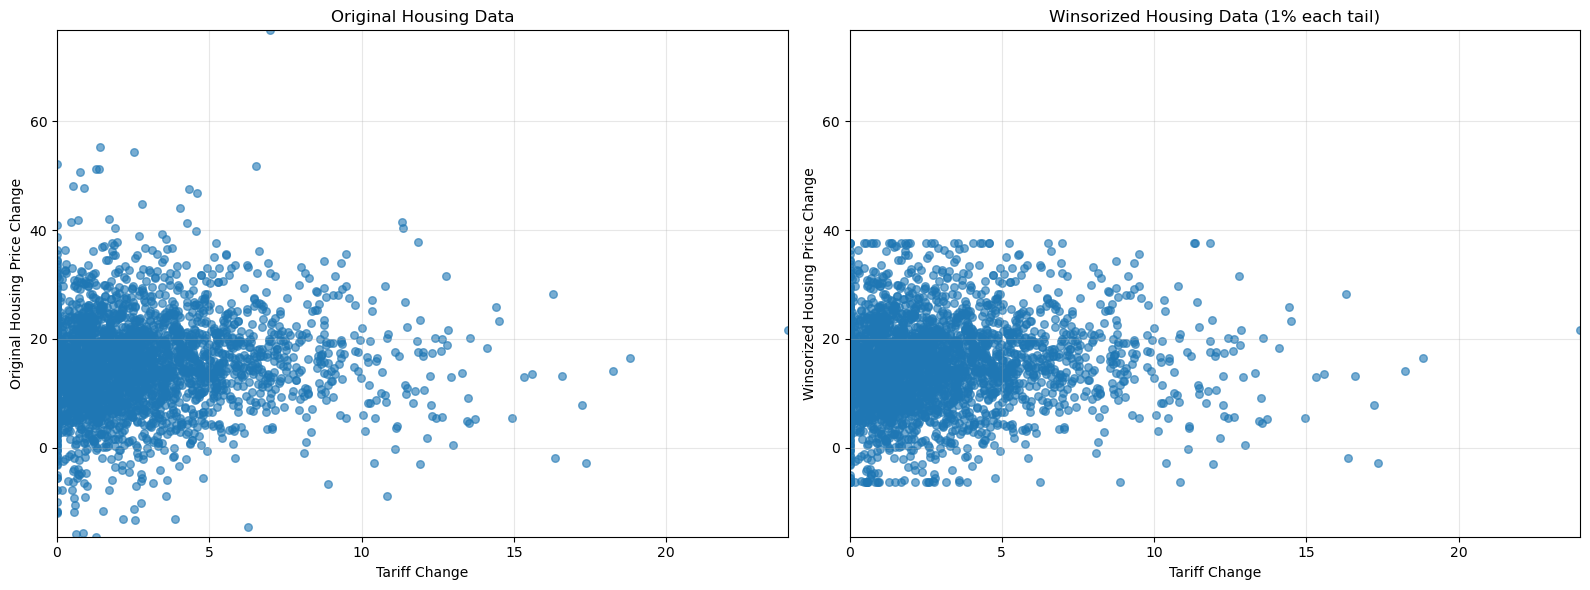

Housing comparison plot (1%) saved to Images/Original_vs_Winsorized_Housing_Comparison_1pct.png


In [13]:
#!/usr/bin/env python
# coding: utf-8

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import os
from datetime import datetime, timedelta

# Load the data
tariff = pd.read_csv('Data/ustariffs-by-county.csv')
zillow = pd.read_csv('Data/zillow county.csv')

# Clean tariff data
tariff_columns_drop = ['Unnamed: 0','total_imp_pc','china_imp_pc','emplvl_2017','total_employment','int_area_fips','2017_income','area_fips']
tariff = tariff.drop(columns=tariff_columns_drop)

# Convert time column and filter date range
tariff['time'] = pd.to_datetime(tariff['time'])
tariff = tariff[(tariff['time'] >= '2017-01-01') & (tariff['time'] <= '2019-12-31')]

# Create pivoted tariff DataFrame
pivoted_tariff = tariff.pivot(index='fips', columns='time', values='tariff')

# Add population data
population_data = tariff.dropna(subset=['2017_population']).drop_duplicates(subset=['fips'], keep='first')[['fips', '2017_population']]
population_data = population_data.set_index('fips')
pivoted_tariff = pivoted_tariff.join(population_data)

# Rename columns to shift dates back by one day (to match original logic)
current_columns = pivoted_tariff.columns.tolist()
column_mapping = {}

for col in current_columns:
    if isinstance(col, str) and '-' in col:  # Check if it's a date string
        try:
            current_date = pd.to_datetime(col)
            new_date = current_date - timedelta(days=1)
            new_date_str = new_date.strftime('%Y-%m-%d')
            column_mapping[col] = new_date_str
        except:
            column_mapping[col] = col
    else:
        column_mapping[col] = col

pivoted_tariff = pivoted_tariff.rename(columns=column_mapping).reset_index()

# Calculate tariff change
first_date = pivoted_tariff.columns[1]  
last_date = pivoted_tariff.columns[-2]  
pivoted_tariff['tariff_change'] = pivoted_tariff[last_date] - pivoted_tariff[first_date]

# Process Zillow data
# Create FIPS code
zillow['StateCodeFIPS'] = zillow['StateCodeFIPS'].astype(str).str.zfill(2)
zillow['MunicipalCodeFIPS'] = zillow['MunicipalCodeFIPS'].astype(str).str.zfill(3)
zillow['fips'] = zillow['StateCodeFIPS'] + zillow['MunicipalCodeFIPS']
zillow['fips'] = zillow['fips'].astype(int)

# Drop unnecessary columns
zillow_drop_columns = ['RegionID','SizeRank','RegionName','RegionType','StateName','State','Metro','StateCodeFIPS','MunicipalCodeFIPS']
zillow = zillow.drop(columns=zillow_drop_columns)

# Keep only fips and date columns between 2017 and 2019
all_columns = zillow.columns.tolist()
columns_to_keep = ['fips']

for column in all_columns:
    if isinstance(column, str) and len(column) == 10 and column[4] == '-' and column[7] == '-':
        try:
            year = int(column.split('-')[0])
            if 2017 <= year <= 2019:
                columns_to_keep.append(column)
        except:
            pass

zillow_filtered = zillow[columns_to_keep]

# Calculate housing price percentage change
zillow_filtered['change'] = (zillow_filtered.iloc[:, -1] - zillow_filtered.iloc[:, 1]) / zillow_filtered.iloc[:, 1] * 100

# Prepare final datasets
zillow_filtered = zillow_filtered[['fips','change']].dropna()
tariff_filtered = pivoted_tariff[['fips','tariff_change','2017_population']]

# Merge the datasets
scatter_data = zillow_filtered.merge(tariff_filtered, how='inner', left_on='fips', right_on='fips')
scatter_data = scatter_data.dropna()

# WINSORIZATION FUNCTION
def winsorize(data, limits=(0.05, 0.05)):
    """
    Winsorize data by replacing extreme values with percentile values.
    
    Parameters:
    data: pandas Series or numpy array
    limits: tuple of (lower_limit, upper_limit) as proportions (e.g., 0.05 = 5%)
    
    Returns:
    winsorized data
    """
    lower_limit, upper_limit = limits
    lower_percentile = lower_limit * 100
    upper_percentile = (1 - upper_limit) * 100
    
    lower_bound = np.percentile(data, lower_percentile)
    upper_bound = np.percentile(data, upper_percentile)
    
    # Create a copy to avoid modifying original data
    winsorized_data = data.copy()
    winsorized_data = np.where(winsorized_data < lower_bound, lower_bound, winsorized_data)
    winsorized_data = np.where(winsorized_data > upper_bound, upper_bound, winsorized_data)
    
    return winsorized_data

# Apply winsorization to housing price changes only (1% on each tail)
print("Original housing price data statistics:")
print(f"Housing price change - Min: {scatter_data['change'].min():.3f}, Max: {scatter_data['change'].max():.3f}")

# Winsorize only the housing price change data (1% each tail)
scatter_data['change_winsorized'] = winsorize(scatter_data['change'], limits=(0.01, 0.01))

print("\nWinsorized housing price data statistics:")
print(f"Housing price change - Min: {scatter_data['change_winsorized'].min():.3f}, Max: {scatter_data['change_winsorized'].max():.3f}")

# Show how many observations were winsorized
housing_winsorized_count = np.sum((scatter_data['change'] != scatter_data['change_winsorized']))

print(f"\nObservations winsorized:")
print(f"Housing price change: {housing_winsorized_count} out of {len(scatter_data)} ({housing_winsorized_count/len(scatter_data)*100:.1f}%)")

# CREATE QUARTILES USING ORIGINAL TARIFF DATA
scatter_data['quartile'] = pd.qcut(scatter_data['tariff_change'], q=4, labels=['Q1', 'Q2', 'Q3', 'Q4'])

# Define colors for each quartile
quartile_colors = {
    'Q1': '#1f77b4',    # Blue for Q1 (highest tariff changes)
    'Q2': '#808080',    # Gray for Q2 and Q3 (middle quartiles)
    'Q3': '#808080',    # Gray for Q2 and Q3 (middle quartiles)  
    'Q4': '#d62728'     # Red for Q4 (lowest tariff changes)
}

# Map colors to each data point
colors = scatter_data['quartile'].map(quartile_colors)

# Prepare data for plotting (winsorized housing, original tariff)
y = scatter_data['change_winsorized']
x = scatter_data['tariff_change']
populations = scatter_data['2017_population']

# Create 6 distinct size categories using population percentiles
population_bins = np.percentile(populations, [0, 16.6, 33.3, 50, 66.6, 83.3, 100])
size_values = [50, 100, 200, 350, 550, 800]

# Assign each data point to a size category
sizes = np.zeros_like(populations, dtype=float)
for i in range(len(population_bins)-1):
    mask = (populations >= population_bins[i]) & (populations <= population_bins[i+1])
    sizes[mask] = size_values[i]

# Create the scatter plot with quartile colors
fig, ax = plt.subplots(figsize=(12, 8))

# Plot each quartile separately for better legend control
legend_labels_added = set()
for quartile in ['Q1', 'Q2', 'Q3', 'Q4']:
    mask = scatter_data['quartile'] == quartile
    
    if quartile in ['Q2', 'Q3']:
        # Combine Q2 and Q3 in legend
        if 'Q2 & Q3' not in legend_labels_added:
            label = 'Q2 & Q3'
            legend_labels_added.add('Q2 & Q3')
        else:
            label = None
    else:
        label = f'{quartile}'
    
    ax.scatter(x[mask], y[mask], s=sizes[mask], 
               c=quartile_colors[quartile], alpha=0.6, 
               label=label, edgecolors='white', linewidth=0.5)

# Calculate and add the line of best fit (using winsorized data)
slope, intercept = np.polyfit(x, y, 1)
x_line = np.array([min(x), max(x)])
y_line = slope * x_line + intercept

# Plot the best fit line as dotted
ax.plot(x_line, y_line, color='black', linestyle='--', linewidth=2, 
         label='Best Fit')

# Create a slope marker
x_marker = x_line[0] + (x_line[1] - x_line[0]) / 3
y_marker = slope * x_marker + intercept

# Draw the slope triangle
dx = (max(x) - min(x)) * 0.1
dy = dx * slope

ax.plot([x_marker, x_marker + dx], [y_marker, y_marker], 'k-', linewidth=1.5)
ax.plot([x_marker + dx, x_marker + dx], [y_marker, y_marker + dy], 'k-', linewidth=1.5)
ax.plot([x_marker, x_marker + dx], [y_marker, y_marker + dy], 'k-', linewidth=1.5)

# Add slope text
ax.text(x_marker + dx/2, y_marker + dy/2 - 2, f'Slope = {slope:.4f}', 
         ha='center', va='center', bbox=dict(facecolor='white', alpha=0.8, edgecolor='black'))

# Set axis limits to match original data scale
original_y_min = scatter_data['change'].min()
original_y_max = scatter_data['change'].max()
original_x_min = scatter_data['tariff_change'].min()
original_x_max = scatter_data['tariff_change'].max()

ax.set_xlim(original_x_min, original_x_max)
ax.set_ylim(original_y_min, original_y_max)

# Customize the plot
ax.set_xlabel('Tariff Percentile Point Change', fontsize=12)
ax.set_ylabel('Housing Price Percent Change (Winsorized 1%)', fontsize=12)
ax.set_title('Housing Price Changes by Tariff Changes - Winsorized Housing Data 1% (Colored by Quartiles)', fontsize=14, pad=20)
ax.grid(True, alpha=0.3)

# Add legend
ax.legend(loc='upper left', frameon=True, fancybox=True, shadow=True)

# Add quartile statistics as text box (winsorized housing, original tariff)
quartile_stats = scatter_data.groupby('quartile').agg({
    'tariff_change': ['min', 'max', 'mean'],
    'change_winsorized': 'mean'
}).round(3)

stats_text = "Quartile Statistics:\n"
for q in ['Q1', 'Q2', 'Q3', 'Q4']:
    tariff_range = f"{quartile_stats.loc[q, ('tariff_change', 'min')]:.3f} to {quartile_stats.loc[q, ('tariff_change', 'max')]:.3f}"
    housing_mean = quartile_stats.loc[q, ('change_winsorized', 'mean')]
    stats_text += f"{q}: Tariff [{tariff_range}], Avg Housing Change: {housing_mean:.2f}%\n"

ax.text(0.98, 0.98, stats_text, transform=ax.transAxes, fontsize=9,
        verticalalignment='top', horizontalalignment='right', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))

plt.tight_layout()

# Save the plot
os.makedirs('Images', exist_ok=True)
output_path = os.path.join('Images', 'Quartile_Scatterplot_Housing_Winsorized_1pct.png')
plt.savefig(output_path, dpi=300, bbox_inches='tight', pad_inches=0.1)
plt.show()

print(f"\nHousing-winsorized (1%) quartile-colored scatterplot saved to {output_path}")
print(f"\nQuartile distribution:")
print(scatter_data['quartile'].value_counts().sort_index())

# Optional: Create comparison plot showing original vs winsorized housing data
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Get the same scale for both plots
y_min = scatter_data['change'].min()
y_max = scatter_data['change'].max()
x_min = scatter_data['tariff_change'].min()
x_max = scatter_data['tariff_change'].max()

# Original data
ax1.scatter(scatter_data['tariff_change'], scatter_data['change'], alpha=0.6, s=30)
ax1.set_xlabel('Tariff Change')
ax1.set_ylabel('Original Housing Price Change')
ax1.set_title('Original Housing Data')
ax1.set_xlim(x_min, x_max)
ax1.set_ylim(y_min, y_max)
ax1.grid(True, alpha=0.3)

# Winsorized housing data
ax2.scatter(scatter_data['tariff_change'], scatter_data['change_winsorized'], alpha=0.6, s=30)
ax2.set_xlabel('Tariff Change')
ax2.set_ylabel('Winsorized Housing Price Change')
ax2.set_title('Winsorized Housing Data (1% each tail)')
ax2.set_xlim(x_min, x_max)
ax2.set_ylim(y_min, y_max)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
comparison_path = os.path.join('Images', 'Original_vs_Winsorized_Housing_Comparison_1pct.png')
plt.savefig(comparison_path, dpi=300, bbox_inches='tight')
plt.show()

print(f"Housing comparison plot (1%) saved to {comparison_path}")

/var/folders/m2/kj3jnz6d03z1s37zqkzg8xbm0000gn/T/ipykernel_81826/4294408354.py:82: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  zillow_filtered['change'] = (zillow_filtered.iloc[:, -1] - zillow_filtered.iloc[:, 1]) / zillow_filtered.iloc[:, 1] * 100


=== REGRESSION STATISTICS (Original Data) ===
Slope: 0.263284
Standard Error of Slope: 0.058049
Intercept: 14.418901
R-squared: 0.006893
P-value: 0.000006

=== STATSMODELS OUTPUT ===
Slope: 0.263284
Standard Error of Slope: 0.058049
t-statistic: 4.535558
95% Confidence Interval for Slope: [0.149464, 0.377105]

=== MANUAL CALCULATION ===
Sample size (n): 2966
Mean Squared Error: 74.013695
Sum of Squares (x): 21964.629342
Standard Error of Slope (manual): 0.058049

=== CONFIDENCE INTERVALS ===
Degrees of Freedom: 2964
t-critical (95%): 1.9608
Margin of Error: 0.113820
95% Confidence Interval: [0.149464, 0.377105]

=== HYPOTHESIS TEST ===
H0: slope = 0
H1: slope ≠ 0
t-statistic: 4.535558
p-value: 0.000006
Result: REJECT H0 - Slope is statistically significant at 5% level


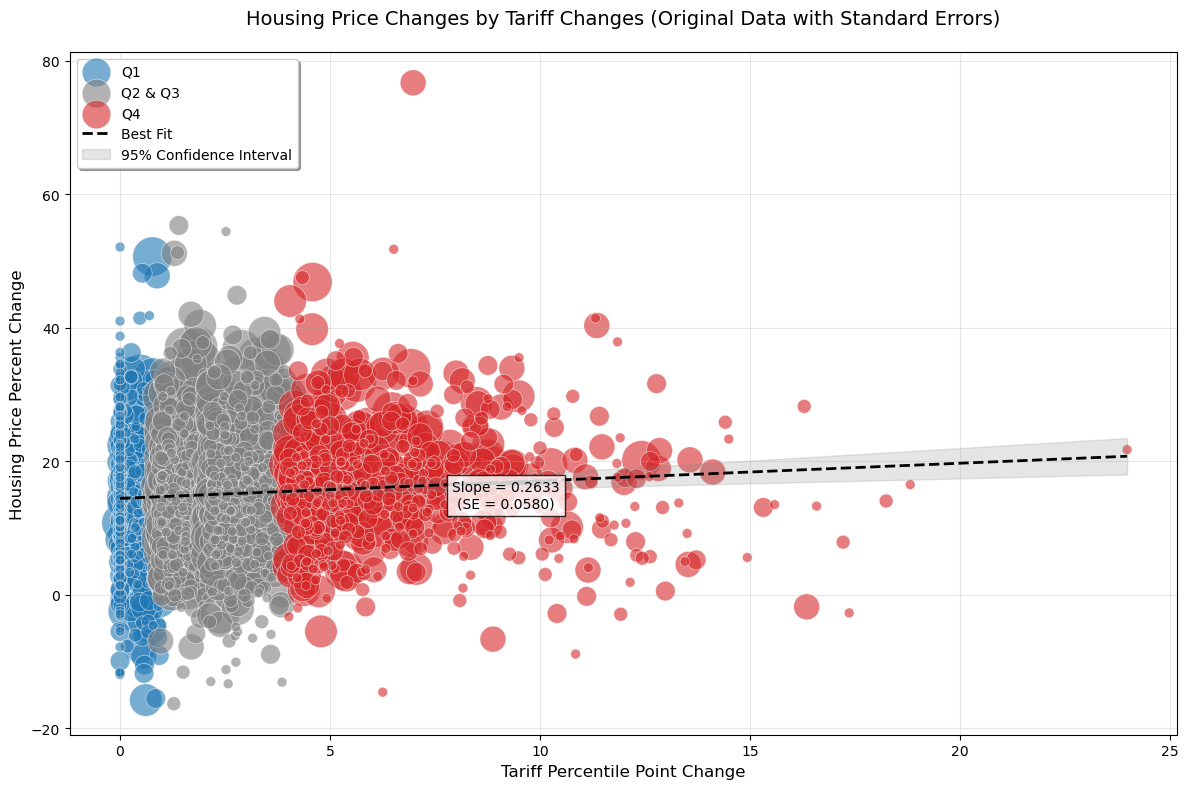


Plot with standard errors saved to Images/Original_Data_with_Standard_Errors.png

=== QUICK REFERENCE ===
Slope ± 1 Standard Error: 0.263284 ± 0.058049
Range: [0.205235, 0.321333]
Slope ± 2 Standard Errors: [0.147186, 0.379382]


In [19]:
#!/usr/bin/env python
# coding: utf-8

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import os
from datetime import datetime, timedelta
from scipy import stats
import statsmodels.api as sm

# Load the data
tariff = pd.read_csv('Data/ustariffs-by-county.csv')
zillow = pd.read_csv('Data/zillow county.csv')

# Clean tariff data
tariff_columns_drop = ['Unnamed: 0','total_imp_pc','china_imp_pc','emplvl_2017','total_employment','int_area_fips','2017_income','area_fips']
tariff = tariff.drop(columns=tariff_columns_drop)

# Convert time column and filter date range
tariff['time'] = pd.to_datetime(tariff['time'])
tariff = tariff[(tariff['time'] >= '2017-01-01') & (tariff['time'] <= '2019-12-31')]

# Create pivoted tariff DataFrame
pivoted_tariff = tariff.pivot(index='fips', columns='time', values='tariff')

# Add population data
population_data = tariff.dropna(subset=['2017_population']).drop_duplicates(subset=['fips'], keep='first')[['fips', '2017_population']]
population_data = population_data.set_index('fips')
pivoted_tariff = pivoted_tariff.join(population_data)

# Rename columns to shift dates back by one day (to match original logic)
current_columns = pivoted_tariff.columns.tolist()
column_mapping = {}

for col in current_columns:
    if isinstance(col, str) and '-' in col:  # Check if it's a date string
        try:
            current_date = pd.to_datetime(col)
            new_date = current_date - timedelta(days=1)
            new_date_str = new_date.strftime('%Y-%m-%d')
            column_mapping[col] = new_date_str
        except:
            column_mapping[col] = col
    else:
        column_mapping[col] = col

pivoted_tariff = pivoted_tariff.rename(columns=column_mapping).reset_index()

# Calculate tariff change
first_date = pivoted_tariff.columns[1]  
last_date = pivoted_tariff.columns[-2]  
pivoted_tariff['tariff_change'] = pivoted_tariff[last_date] - pivoted_tariff[first_date]

# Process Zillow data
# Create FIPS code
zillow['StateCodeFIPS'] = zillow['StateCodeFIPS'].astype(str).str.zfill(2)
zillow['MunicipalCodeFIPS'] = zillow['MunicipalCodeFIPS'].astype(str).str.zfill(3)
zillow['fips'] = zillow['StateCodeFIPS'] + zillow['MunicipalCodeFIPS']
zillow['fips'] = zillow['fips'].astype(int)

# Drop unnecessary columns
zillow_drop_columns = ['RegionID','SizeRank','RegionName','RegionType','StateName','State','Metro','StateCodeFIPS','MunicipalCodeFIPS']
zillow = zillow.drop(columns=zillow_drop_columns)

# Keep only fips and date columns between 2017 and 2019
all_columns = zillow.columns.tolist()
columns_to_keep = ['fips']

for column in all_columns:
    if isinstance(column, str) and len(column) == 10 and column[4] == '-' and column[7] == '-':
        try:
            year = int(column.split('-')[0])
            if 2017 <= year <= 2019:
                columns_to_keep.append(column)
        except:
            pass

zillow_filtered = zillow[columns_to_keep]

# Calculate housing price percentage change
zillow_filtered['change'] = (zillow_filtered.iloc[:, -1] - zillow_filtered.iloc[:, 1]) / zillow_filtered.iloc[:, 1] * 100

# Prepare final datasets
zillow_filtered = zillow_filtered[['fips','change']].dropna()
tariff_filtered = pivoted_tariff[['fips','tariff_change','2017_population']]

# Merge the datasets
scatter_data = zillow_filtered.merge(tariff_filtered, how='inner', left_on='fips', right_on='fips')
scatter_data = scatter_data.dropna()

# CALCULATE STANDARD ERROR OF THE SLOPE - Multiple Methods

# Method 1: Using scipy.stats.linregress (most common)
x = scatter_data['tariff_change']
y = scatter_data['change']

slope, intercept, r_value, p_value, std_err = stats.linregress(x, y)

print("=== REGRESSION STATISTICS (Original Data) ===")
print(f"Slope: {slope:.6f}")
print(f"Standard Error of Slope: {std_err:.6f}")
print(f"Intercept: {intercept:.6f}")
print(f"R-squared: {r_value**2:.6f}")
print(f"P-value: {p_value:.6f}")

# Method 2: Using statsmodels for more detailed output
X = sm.add_constant(x)  # Add intercept term
model = sm.OLS(y, X).fit()

print(f"\n=== STATSMODELS OUTPUT ===")
print(f"Slope: {model.params[1]:.6f}")
print(f"Standard Error of Slope: {model.bse[1]:.6f}")
print(f"t-statistic: {model.tvalues[1]:.6f}")
print(f"95% Confidence Interval for Slope: [{model.conf_int().iloc[1,0]:.6f}, {model.conf_int().iloc[1,1]:.6f}]")

# Method 3: Manual calculation (for understanding)
n = len(x)
y_pred = slope * x + intercept
residuals = y - y_pred
mse = np.sum(residuals**2) / (n - 2)  # Mean squared error
x_mean = np.mean(x)
ss_x = np.sum((x - x_mean)**2)  # Sum of squares of x
manual_std_err = np.sqrt(mse / ss_x)

print(f"\n=== MANUAL CALCULATION ===")
print(f"Sample size (n): {n}")
print(f"Mean Squared Error: {mse:.6f}")
print(f"Sum of Squares (x): {ss_x:.6f}")
print(f"Standard Error of Slope (manual): {manual_std_err:.6f}")

# Calculate confidence intervals
confidence_level = 0.95
alpha = 1 - confidence_level
degrees_freedom = n - 2
t_critical = stats.t.ppf(1 - alpha/2, degrees_freedom)

margin_of_error = t_critical * std_err
lower_bound = slope - margin_of_error
upper_bound = slope + margin_of_error

print(f"\n=== CONFIDENCE INTERVALS ===")
print(f"Degrees of Freedom: {degrees_freedom}")
print(f"t-critical (95%): {t_critical:.4f}")
print(f"Margin of Error: {margin_of_error:.6f}")
print(f"95% Confidence Interval: [{lower_bound:.6f}, {upper_bound:.6f}]")

# Test significance
print(f"\n=== HYPOTHESIS TEST ===")
print(f"H0: slope = 0")
print(f"H1: slope ≠ 0")
t_statistic = slope / std_err
print(f"t-statistic: {t_statistic:.6f}")
print(f"p-value: {p_value:.6f}")
if p_value < 0.05:
    print("Result: REJECT H0 - Slope is statistically significant at 5% level")
else:
    print("Result: FAIL TO REJECT H0 - Slope is not statistically significant at 5% level")

# CREATE QUARTILES USING METHOD 2 (pandas qcut)
scatter_data['quartile'] = pd.qcut(scatter_data['tariff_change'], q=4, labels=['Q1', 'Q2', 'Q3', 'Q4'])

# Define colors for each quartile
quartile_colors = {
    'Q1': '#1f77b4',    # Blue for Q1 (highest tariff changes)
    'Q2': '#808080',    # Gray for Q2 and Q3 (middle quartiles)
    'Q3': '#808080',    # Gray for Q2 and Q3 (middle quartiles)  
    'Q4': '#d62728'     # Red for Q4 (lowest tariff changes)
}

# Map colors to each data point
colors = scatter_data['quartile'].map(quartile_colors)

# Prepare data for plotting
populations = scatter_data['2017_population']

# Create 6 distinct size categories using population percentiles
population_bins = np.percentile(populations, [0, 16.6, 33.3, 50, 66.6, 83.3, 100])
size_values = [50, 100, 200, 350, 550, 800]

# Assign each data point to a size category
sizes = np.zeros_like(populations, dtype=float)
for i in range(len(population_bins)-1):
    mask = (populations >= population_bins[i]) & (populations <= population_bins[i+1])
    sizes[mask] = size_values[i]

# Create the scatter plot with quartile colors
fig, ax = plt.subplots(figsize=(12, 8))

# Plot each quartile separately for better legend control
legend_labels_added = set()
for quartile in ['Q1', 'Q2', 'Q3', 'Q4']:
    mask = scatter_data['quartile'] == quartile
    
    if quartile in ['Q2', 'Q3']:
        # Combine Q2 and Q3 in legend
        if 'Q2 & Q3' not in legend_labels_added:
            label = 'Q2 & Q3'
            legend_labels_added.add('Q2 & Q3')
        else:
            label = None
    else:
        label = f'{quartile}'
    
    ax.scatter(x[mask], y[mask], s=sizes[mask], 
               c=quartile_colors[quartile], alpha=0.6, 
               label=label, edgecolors='white', linewidth=0.5)

# Calculate and add the line of best fit
x_line = np.array([min(x), max(x)])
y_line = slope * x_line + intercept

# Plot the best fit line as dotted
ax.plot(x_line, y_line, color='black', linestyle='--', linewidth=2, 
         label='Best Fit')

# Add confidence interval bands
y_line_upper = (slope + margin_of_error) * x_line + intercept
y_line_lower = (slope - margin_of_error) * x_line + intercept

ax.fill_between(x_line, y_line_lower, y_line_upper, alpha=0.2, color='gray', 
                label='95% Confidence Interval')

# Create a slope marker
x_marker = x_line[0] + (x_line[1] - x_line[0]) / 3
y_marker = slope * x_marker + intercept

# Draw the slope triangle
dx = (max(x) - min(x)) * 0.1
dy = dx * slope

ax.plot([x_marker, x_marker + dx], [y_marker, y_marker], 'k-', linewidth=1.5)
ax.plot([x_marker + dx, x_marker + dx], [y_marker, y_marker + dy], 'k-', linewidth=1.5)
ax.plot([x_marker, x_marker + dx], [y_marker, y_marker + dy], 'k-', linewidth=1.5)

# Add slope text with standard error
ax.text(x_marker + dx/2, y_marker + dy/2 - 2, 
         f'Slope = {slope:.4f}\n(SE = {std_err:.4f})', 
         ha='center', va='center', bbox=dict(facecolor='white', alpha=0.8, edgecolor='black'))

# Customize the plot
ax.set_xlabel('Tariff Percentile Point Change', fontsize=12)
ax.set_ylabel('Housing Price Percent Change', fontsize=12)
ax.set_title('Housing Price Changes by Tariff Changes (Original Data with Standard Errors)', fontsize=14, pad=20)
ax.grid(True, alpha=0.3)

# Add legend
ax.legend(loc='upper left', frameon=True, fancybox=True, shadow=True)

# Add regression statistics as text box
stats_text = f"Regression Statistics:\n"
stats_text += f"Slope: {slope:.6f} (SE: {std_err:.6f})\n"
stats_text += f"t-stat: {t_statistic:.3f}, p-value: {p_value:.6f}\n"
stats_text += f"R²: {r_value**2:.4f}\n"
stats_text += f"95% CI: [{lower_bound:.6f}, {upper_bound:.6f}]\n"
stats_text += f"Sample size: {n}"

ax.text(0.02, 0.98, stats_text, transform=ax.transAxes, fontsize=9,
        verticalalignment='top', horizontalalignment='left', 
        bbox=dict(boxstyle='round', facecolor='lightblue', alpha=0.8))

plt.tight_layout()

# Save the plot
os.makedirs('Images', exist_ok=True)
output_path = os.path.join('Images', 'Original_Data_with_Standard_Errors.png')
plt.savefig(output_path, dpi=300, bbox_inches='tight', pad_inches=0.1)
plt.show()

print(f"\nPlot with standard errors saved to {output_path}")

# Summary for easy reference
print(f"\n=== QUICK REFERENCE ===")
print(f"Slope ± 1 Standard Error: {slope:.6f} ± {std_err:.6f}")
print(f"Range: [{slope - std_err:.6f}, {slope + std_err:.6f}]")
print(f"Slope ± 2 Standard Errors: [{slope - 2*std_err:.6f}, {slope + 2*std_err:.6f}]")